In [1]:
import pandas as pd

## DataFrames

- The `pandas` module provides a powerful data-structure called a data frame.

- It is similar, but not identical to an Excel spreadsheet,

- A data frame has multiple columns, each of which can hold a *different* type of value.

- Like a series, it has an index which provides a label for each and every row. 


    

## Loading Files with Pandas
- We used Pandas in an earlier notebook to load the iris data file.  
- Whenver you have a dataset with a variety of fields of various types, loading it into Pandas is a good strategy.
- You can load data from Azure, from a local file, or from a url.  







In [130]:
# We can load .csv files, but also .zip files which contain .csv files
df = pd.read_csv('data/titles.zip')
cast = pd.read_csv('data/cast.zip')

## Taking a quick look of the dataframe.

- We can quickly see the top contents of a dataframe by using `df.head()`.
- By default, this will show the first 5 entries, but `head()` takes an argument to specify if you want more or less.
- A similar method is `.tail()` which shows the bottom entries.

In [133]:
cast.head()

,title,year,name,type,character,n
0,Transformers: Revenge of the Fallen,2009,Leon 'Vietnam'Carswell,actor,Tribesman,NaN
1,Kung ako na lang sana,2003,Artemio Abad,actor,Greg's Barkada at Party,36.0
2,Around the World in 80 Days,1956,Leo Abbey,actor,Extra,NaN
3,"Blackbeard, the Pirate",1952,Leo Abbey,actor,Pirate,NaN
4,God Is My Co-Pilot,1945,Leo Abbey,actor,Ground Crewman,NaN


In [134]:
cast.head(3)

,title,year,name,type,character,n
0,Transformers: Revenge of the Fallen,2009,Leon 'Vietnam'Carswell,actor,Tribesman,NaN
1,Kung ako na lang sana,2003,Artemio Abad,actor,Greg's Barkada at Party,36.0
2,Around the World in 80 Days,1956,Leo Abbey,actor,Extra,NaN


## Functions and DataFrames

- We can do calculations and functions with dataframes just like series.
- Functions will typically return a dataframe or a series, depending. 
- To make a copy, don't assign the dataframe to a new variable, instead use the `copy` method shown below:  
`df2= df.copy()` (same as lists)

In [135]:
#Info
nulls=cast.isnull()
print(nulls, "\n", type(nulls))

nullsum=nulls.sum()

print("\nNull sum for each column \n", nullsum, "\n", type(nullsum))

# print("\nWe can slice these results to get the answer for x \n", nullsum.x)
# type(nullsum.x)

       title   year   name   type  character      n
0      False  False  False  False      False   True
1      False  False  False  False      False  False
2      False  False  False  False      False   True
3      False  False  False  False      False   True
4      False  False  False  False      False   True
...      ...    ...    ...    ...        ...    ...
16743  False  False  False  False      False  False
16744  False  False  False  False      False   True
16745  False  False  False  False      False  False
16746  False  False  False  False      False  False
16747  False  False  False  False      False   True

[16748 rows x 6 columns] 
 <class 'pandas.core.frame.DataFrame'>

Null sum for each column 
 title           0
year            0
name            0
type            0
character       0
n            6778
dtype: int64 
 <class 'pandas.core.series.Series'>


## Summary statistics
- To quickly obtain summary statistics on numerical values use the `describe` method.
- You will get a warning if there are missing values.

In [136]:
cast.describe()

,year,n
count,16748.000000,9970.000000
mean,1980.321352,15.570311
std,29.628988,20.306151
min,1911.000000,1.000000
25%,1953.000000,5.000000
50%,1987.000000,10.000000
75%,2009.000000,20.000000
max,2020.000000,487.000000


### Data Types and shape
- Each will have an inferred data type. 

In [137]:
print(cast.dtypes)

title         object
year           int64
name          object
type          object
character     object
n            float64
dtype: object


In [138]:
# .shape gives the total number of rows and columns
print(df.shape)
# .len gives the total number of rows
print(len(df))

(226013, 2)
226013


# Accessing the Row and Column Labels

- The row labels (index) can be accessed through `df.index`.
- The column labels can be accessed through `df.columns`.


In [139]:
cast.index

RangeIndex(start=0, stop=16748, step=1)

In [140]:
cast.columns

Index(['title', 'year', 'name', 'type', 'character', 'n'], dtype='object')

## Indexing/Slicing Rows of DataFrames
- Simple ways of selecting all rows and columns (`df[:]`)
- Rows can be accessed via a key or a integer corresponding to the row number. 
- Omitting a value generally means *all values* before or after an item.
- When we retrieve a single or mulitiple rows, the result is a Dataframe.
- Several ways, either directly, with `iloc`, or with `loc`. (See Examples).
- Read more [here](http://pandas.pydata.org/pandas-docs/stable/indexing.html)



## Selecting Rows
- Similarly, we also might want to select out rows, and we can utilize the same syntax.
- [iloc](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.iloc.html)

In [141]:

## Selecting rows
print (df[0:3])     #Select rows 1-3
print (df.iloc[0:3,:])     #Select rows 1-3
print (df.iloc[0:3,])      #Select rows 1-3
print (df.iloc[0:3])       #Select rows 1-3
print (df.iloc[[1,2,4]])   #Select rows 1, 2, and 4


                       title  year
0       The Hell with Heroes  1968
1  Raptola, violola y matola  1989
2       Kigeki: Otto urimasu  1968
                       title  year
0       The Hell with Heroes  1968
1  Raptola, violola y matola  1989
2       Kigeki: Otto urimasu  1968
                       title  year
0       The Hell with Heroes  1968
1  Raptola, violola y matola  1989
2       Kigeki: Otto urimasu  1968
                       title  year
0       The Hell with Heroes  1968
1  Raptola, violola y matola  1989
2       Kigeki: Otto urimasu  1968
                       title  year
1  Raptola, violola y matola  1989
2       Kigeki: Otto urimasu  1968
4        Burning an Illusion  1981


## Selecting a particular column
- We can filter a particular row by indexing it by name as `df['column_name']
- If the column name is in lower case without spaces, we can call it as `df.column_name`

In [142]:
cast['title'].head()

0    Transformers: Revenge of the Fallen
1                  Kung ako na lang sana
2            Around the World in 80 Days
3                 Blackbeard, the Pirate
4                     God Is My Co-Pilot
Name: title, dtype: object

## Pandas Series 
- A `dataframe` can be thought of as a collection of `series` objects.
- You can distinguish between a `dataframe` and `series` by the formatting in a jupyter notebook.
- Any column selected as `df['column_name']` will give you a series.
- If you want a dataframe with a single column instead of a series, you can pass a single item list to a dataframe as `df[['column_name']]`
![](https://storage.googleapis.com/lds-media/images/series-and-dataframe.original.png)

In [143]:
df.head()

,title,year
0,The Hell with Heroes,1968
1,"Raptola, violola y matola",1989
2,Kigeki: Otto urimasu,1968
3,Tanga-Tika,1953
4,Burning an Illusion,1981


In [144]:
df['title']

0              The Hell with Heroes
1         Raptola, violola y matola
2              Kigeki: Otto urimasu
3                        Tanga-Tika
4               Burning an Illusion
                    ...            
226008                       Gringo
226009              Nurse on Wheels
226010                     Lav-Kush
226011       Hammers Over the Anvil
226012      The Passionate Stranger
Name: title, Length: 226013, dtype: object

In [145]:
type(df['title'])

pandas.core.series.Series

In [146]:
type(df[['title']])

pandas.core.frame.DataFrame

## Intro to Filters (Logical indexing)
- Filters are the selection of rows based on criteria.
- We can select based on specific criteria.
- These criteria can be connected together.
- Most of the time we won't specfically assign selection critia to a list. 

In [147]:
# At the foundation of the filter is a boolean array based on some type of condition. 
print(df)
df['year'] >= 2000

                            title  year
0            The Hell with Heroes  1968
1       Raptola, violola y matola  1989
2            Kigeki: Otto urimasu  1968
3                      Tanga-Tika  1953
4             Burning an Illusion  1981
...                           ...   ...
226008                     Gringo  1985
226009            Nurse on Wheels  1963
226010                   Lav-Kush  1967
226011     Hammers Over the Anvil  1993
226012    The Passionate Stranger  1957

[226013 rows x 2 columns]


0         False
1         False
2         False
3         False
4         False
          ...  
226008    False
226009    False
226010    False
226011    False
226012    False
Name: year, Length: 226013, dtype: bool

In [148]:
#notice how the logical statement is inside the dataframe specification.  This creates an intermediate boolean array. 
df[df['year'] >= 2000]

,title,year
5,"Swades: We, the People",2004
9,Zutaboro,2015
10,On_Line,2002
14,I'm Very Much in Love with You,2018
18,Umut adasi,2006
...,...,...
225995,Fleurs du mal,2010
225998,Tchnienie,2019
226000,The Circle,2002
226001,Season of the Witch,2011


In [149]:
#This is an alternate method where we first set the boolean array. 
included=df['year'] >= 2000
df[included]


,title,year
5,"Swades: We, the People",2004
9,Zutaboro,2015
10,On_Line,2002
14,I'm Very Much in Love with You,2018
18,Umut adasi,2006
...,...,...
225995,Fleurs du mal,2010
225998,Tchnienie,2019
226000,The Circle,2002
226001,Season of the Witch,2011


In [150]:
#We can now generate a vector based on a critera and then use this for selection
select = df['year']>=2000
print(select,type(select))
print(df.loc[select,:]) #Notice by including only one variable we are selecting rows and all columns.

0         False
1         False
2         False
3         False
4         False
          ...  
226008    False
226009    False
226010    False
226011    False
226012    False
Name: year, Length: 226013, dtype: bool <class 'pandas.core.series.Series'>
                                 title  year
5               Swades: We, the People  2004
9                             Zutaboro  2015
10                             On_Line  2002
14      I'm Very Much in Love with You  2018
18                          Umut adasi  2006
...                                ...   ...
225995                   Fleurs du mal  2010
225998                       Tchnienie  2019
226000                      The Circle  2002
226001             Season of the Witch  2011
226005                  Petrang kabayo  2010

[101821 rows x 2 columns]


## Operations on `Series` 
- By a single command, we can operate on all rows of a series.
- For eg. to get the decade in which the movie is released, we could perform `df['year']//10 * 10`

In [151]:
# Operations on series
(df.year //10 * 10)

0         1960
1         1980
2         1960
3         1950
4         1980
          ... 
226008    1980
226009    1960
226010    1960
226011    1990
226012    1950
Name: year, Length: 226013, dtype: int64

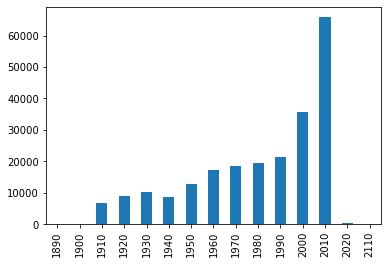

In [152]:
# use value_counts() to aggregate decades
c = (df.year//10 *10).value_counts()
# use .sort_index() to get index sorted
c = c.sort_index()
c.head()
# use .plot(kind='bar') to get a bar plot
c.plot(kind = 'bar')

## Pandas indexing
- We can drop the default numerical index by casting one of the columns as an index using `set_index()`.
- We can then use `sort_index()` method which allows quick lookups of data.

In [156]:
%%time
cast[(cast.title=='The Karate Kid') & (cast.year == 1984)].head()

CPU times: user 3.78 ms, sys: 714 µs, total: 4.49 ms
Wall time: 4.06 ms


,title,year,name,type,character,n
13,The Karate Kid,1984,David Abbott,actor,Yahoo #2,29.0
562,The Karate Kid,1984,Frank Burt Avalon,actor,Chucky,16.0
651,The Karate Kid,1984,William Bassett,actor,Mr. Mills,12.0
1680,The Karate Kid,1984,Chris Casamassa,actor,Tournament Guest,NaN
2258,The Karate Kid,1984,Ken Daly,actor,Chris,18.0


In [157]:
# Setting the index to movie titles and sorting it 
c = cast.set_index(['title']).sort_index()
c.head()

,year,name,type,character,n
title,,,,,
#Y,2014,Leonardo (II) Santos,actor,Party Animal,71.0
#Y,2014,Randolph Leongson,actor,Party Animal,83.0
#Y,2014,Leonora Torres,actress,Church Goer,43.0
$9.99,2008,Leon Ford,actor,Stanton,13.0
'49-'17,1917,Leo Pierson,actor,Tom Reeves - aka Tom Robbins,2.0


In [163]:
%%time
# Comparing its speed to the operation above 
c.loc['The Karate Kid']

CPU times: user 440 µs, sys: 82 µs, total: 522 µs
Wall time: 457 µs


,year,name,type,character,n
title,,,,,
The Karate Kid,1984,Juli Fields,actress,Susan,14.0
The Karate Kid,2010,Xinhua Guo,actor,Tournament Doctor,20.0
The Karate Kid,1984,Darryl Vidal,actor,Karate Semi-Finalist,22.0
The Karate Kid,1984,Martin Kove,actor,Kreese,4.0
The Karate Kid,1984,William Zabka,actor,Johnny,6.0
...,...,...,...,...,...
The Karate Kid,1984,Andrew Shue,actor,Member of Cobra Kai,NaN
The Karate Kid,1984,Frances Bay,actress,Lady with Dog,23.0
The Karate Kid,1984,Donald DeNoyer,actor,Karate Student,NaN


## Groupby operations
- Since it is so common to pull information from various columns, we have an aggregator method called `groupby()`
- Using `groupby()` will return a `groupby` object. We can then use methods such as `size()`,`mean()`,`max()`,`min()` on this which will combine the remaining columns.
- The output of a `groupby()` operation maybe a `Series` or a `Dataframe` depending on the number of columns after the operation. The input of `groupby()` could be any column, or even an operation on a particular column.
![Example of a `groupby()` operation](https://miro.medium.com/max/1838/0*m-puRNwcnUl5zZ4O)

In [164]:
# Finding the total number of movies by Leonardo Dicaprio in each year
c = cast[cast.name == 'Leonardo DiCaprio']
c.groupby('year').size()

year
1992    1
1993    2
1995    3
1996    2
1997    1
1998    3
2000    1
2001    1
2002    2
2004    1
2006    2
2008    2
2009    1
2010    2
2011    1
2012    1
2013    2
2015    1
2018    1
dtype: int64

In [165]:
# Finding the total number of movies by Leonardo Dicaprio in each decade
c = cast[cast.name == 'Leonardo DiCaprio']
c.groupby(c.year//10*10).size()

year
1990    12
2000    10
2010     8
dtype: int64

## Merging Dataframes
- Often you need to combine dataframes with similar information
- We can use the `.merge()` method to do this.
- Below we combine information from `cast.csv` and `release_dates.csv`.

In [166]:
# We call a new dataframe that gives us the release dates for each of the movies 
release_dates = pd.read_csv('data/release_dates.zip')
release_dates.head()

,title,year,country,date
0,"#73, Shaanthi Nivaasa",2007,India,2007-06-15
1,#BKKY,2016,Cambodia,2017-10-12
2,#Beings,2015,Romania,2015-01-29
3,#Captured,2017,USA,2017-09-05
4,#Ewankosau saranghaeyo,2015,Philippines,2015-01-21


In [167]:
# Selecting all roles in movies by Leonardo DiCaprio
c = cast[cast.name == 'Leonardo DiCaprio']
c.head()

,title,year,name,type,character,n
3033,Blood Diamond,2006,Leonardo DiCaprio,actor,Danny Archer,1.0
3034,Body of Lies,2008,Leonardo DiCaprio,actor,Roger Ferris,1.0
3035,Catch Me If You Can,2002,Leonardo DiCaprio,actor,Frank Abagnale Jr.,1.0
3036,Celebrity,1998,Leonardo DiCaprio,actor,Brandon Darrow,93.0
3037,Django Unchained,2012,Leonardo DiCaprio,actor,Calvin Candie,3.0


In [168]:
# Merging with release_dates.csv to get information on the release dates of the above movies
d = c.merge(release_dates)
d.head()

,title,year,name,type,character,n,country,date
0,Blood Diamond,2006,Leonardo DiCaprio,actor,Danny Archer,1.0,USA,2006-12-08
1,Blood Diamond,2006,Leonardo DiCaprio,actor,Danny Archer,1.0,Australia,2007-01-04
2,Blood Diamond,2006,Leonardo DiCaprio,actor,Danny Archer,1.0,Singapore,2007-01-04
3,Blood Diamond,2006,Leonardo DiCaprio,actor,Danny Archer,1.0,Thailand,2007-01-04
4,Blood Diamond,2006,Leonardo DiCaprio,actor,Danny Archer,1.0,Brazil,2007-01-05


In [169]:
# Checking the dtypes
d.dtypes

title         object
year           int64
name          object
type          object
character     object
n            float64
country       object
date          object
dtype: object

In [170]:
# Since the date column is not a datetime object by default, we will need to convert it
d.date = pd.to_datetime(d.date)

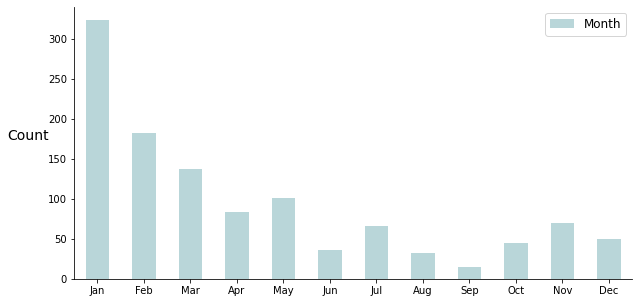

In [171]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(10,5))
# color = ['#CDC8E1','#B9D6D9','#EA9A98']
# d.groupby(['name',d.date.dt.month]).size().unstack(0).apply(lambda x: x / x.max()).plot(kind='bar',ax=ax,color = color,width=0.6)
d.date.dt.month.value_counts().sort_index().plot(kind='bar',ax=ax,color = '#B9D6D9',label='Month')
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],rotation=0)
ax.legend(fontsize=12)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.patch.set_facecolor('None')
ax.set_ylabel('Count',fontsize=14,rotation=0,labelpad=20);

## Saving Dataframes to disk
- Often you need save your analysis to your system.
- You can do this by using the `.to_csv()` method.
- `.to_csv()` takes a filename as an argument and several optional arguments. More [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html)

In [0]:
# This will save the file to the disk at the location where the pandas file is used
d.to_csv('filename.csv',index=False)